<a href="https://colab.research.google.com/github/D1778/ML-lab-2547220/blob/LAB1/lab1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1

In [ ]:
import pandas as pd
citydata=pd.read_csv('city_day.csv')
cropdata=pd.read_csv('crop_production.csv')
print("\n THE REQUIRED INFORMATION ABOUT THE DATASET IS GIVEN BELOW \n")
print("\n The number of rows and columns in the city data and crop data is: \n")
print("CITY DATA ROWS: ",citydata.shape[0])
print("CITY DATA COLUMNS: ",citydata.shape[1])
print("CROP DATA ROWS: ",cropdata.shape[0])
print("CROP DATA COLUMNS: ",cropdata.shape[1])
print("\n The missing values in these two datasets are: \n")
print("CITY DATA MISSING VALUES: \n",citydata.isnull().sum())
print("CROP DATA MISSING VALUES: \n",cropdata.isnull().sum())
print("The datatype of these two datasets are: \n")
print("CITY DATA DATATYPES: \n",citydata.dtypes)
print("\n CROP DATA DATATYPES: \n",cropdata.dtypes)
print("\n Duplicates in the datasets are:\n")
print("CITY DATA duplicates: ",citydata.duplicated().sum())
print("CROP DATA duplicates: ",cropdata.duplicated().sum())






 THE REQUIRED INFORMATION ABOUT THE DATASET IS GIVEN BELOW 


 The number of rows and columns in the city data and crop data is: 

CITY DATA ROWS:  29531
CITY DATA COLUMNS:  16
CROP DATA ROWS:  246091
CROP DATA COLUMNS:  7

 The missing values in these two datasets are: 

CITY DATA MISSING VALUES: 
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
CROP DATA MISSING VALUES: 
 State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64
The datatype of these two datasets are: 

CITY DATA DATATYPES: 
 City           object
Date           object
PM2.5         float64
PM10          float64
NO            flo

The things a data scientist should know before accessing the dataset should be its properties that includes the shape (rows,columns) as well as its datatypes. Data scientist also checks whether it consists the duplicate values and the amount of missing values in the datasets.

So by looking at this datasets provided we can see that:
In the city data that consists of city air quality dataset information:
the CITY DATA ROWS is  29531 and the CITY DATA COLUMNS is  16. 0 duplicates found with extremely severe missing values in the dataset given. In the set of missing values: Xylene tops with 18109 missing values. City and date columns are the ones with 0 missing values.
The datatypes used are of object and float types.

In the crop data we see there are 246091 rows and 7 columns. With 0 duplicates found. The datatypes are of object, float and int respectively. The missing values comes under production where it has around 3730 missing values in it. All others are having 0 missing values in the dataset.

The MAJOR CONCERNS AND PROBLEMS can be:
1. The missing values in the dataset especially when comes to crop data the production column has around 3730 missing values which can lead to effectively useless for the final analysis if not carefully looked over.

2. mismatch in dates: We see in the crop data the caluculation is done by years whereas in the city data daily information is given with proper date as well.. so by comaparing two data this should be checked well.

TASK 2

In [ ]:
print("\n Missing values are:\n")
print("CITY DATA MISSING VALUES: \n",citydata.isnull().sum())
print("CROP DATA MISSING VALUES: \n",cropdata.isnull().sum())
citydata=pd.read_csv('city_day.csv')
cropdata=pd.read_csv('crop_production.csv')
#1
citydata=citydata.drop(columns=["Xylene"])
#2
citydata=citydata.dropna(subset=["AQI","AQI_Bucket"])
cropdata=cropdata.dropna(subset=["Production"])
#3
pollutant=['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
citydata[pollutant] = citydata[pollutant].fillna(citydata[pollutant].median(numeric_only=True))
print("\n After the treatment:\n")
print("CITY DATA MISSING VALUES: \n",citydata.isnull().sum())
print("CROP DATA MISSING VALUES: \n",cropdata.isnull().sum())


 Missing values are:

CITY DATA MISSING VALUES: 
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
CROP DATA MISSING VALUES: 
 State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

 After the treatment:

CITY DATA MISSING VALUES: 
 City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64
CROP DATA MISSING VALUES: 
 State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop        

We have to deal with the missing values in the dataset simple deleting or imputing all columns will not work as we should carefully implement it accoridngly to the need of it.

1. In the city dataset drop the column Xylene because it consists of 18109/29531 missing values that is 61% of the column. It is better to delete it entirely.

2. The production in the crop dataset(3730) and AQI/AQI BUCKET (4681) it is better to drop the rows as imputing values does not make sense as it ruins the integrity of the analysis.

3. Using median in other existing rows rather than mean suggest that to avoid using mean as it distorted of its normal pollution to extremely high ones even in normal days but using median will help to identify that missing among the possible polutions in the dates.

TASK 3

In [ ]:
print("Before removing duplicates:")
print("City data rows:", len(citydata))
print("Crop data rows:", len(cropdata))

cropdata['State_Name'] = cropdata['State_Name'].str.strip()

citymapstate = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}

citydata['State'] = citydata['City'].map(citymapstate)

citydata = citydata.drop_duplicates()
cropdata = cropdata.drop_duplicates()

print("\nAfter removing duplicates:")
print("City data rows:", len(citydata))
print("Crop data rows:", len(cropdata))

Before removing duplicates:
City data rows: 24850
Crop data rows: 242361

After removing duplicates:
City data rows: 24850
Crop data rows: 242361


two datasets has to be joined based on the column of STATE as a commonn key.
1. We see missing state column in the city data as they have only city. need to create state column physically by mapping each city to its correct state.
Solution is to Create a dictionary mapping all 26 unique cities like chennai--coimbatore to their standardized State names to artificially generate the common key required for the merge.

2. There are some invisible trailing spaces that should be sorted out for example like telangana.
To apply str.strip() string method to mathematically strip all leading and trailing whitspaces across the column.

3. check for duplicates and remove it accordingly and print result before and after the process.
use drop_duplicates() function to do this process.

TASK 4

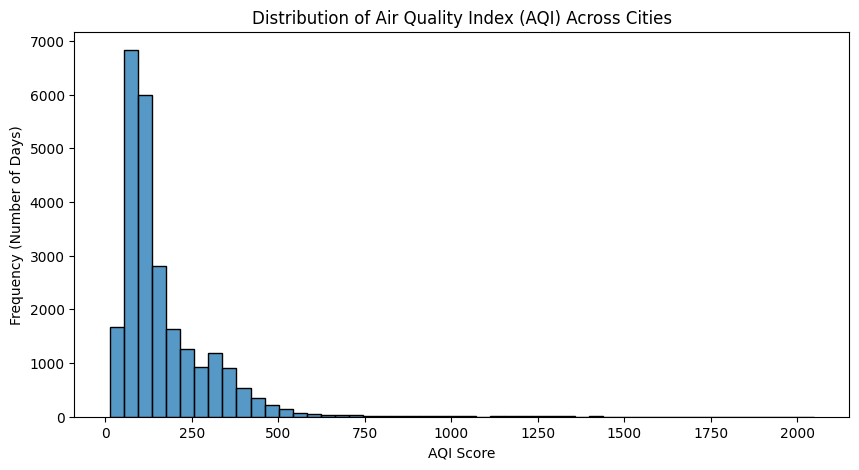

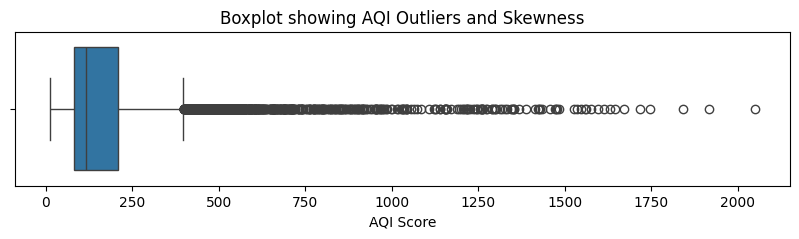

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(citydata['AQI'], bins=50)
plt.title('Distribution of Air Quality Index (AQI) Across Cities')
plt.xlabel('AQI Score')
plt.ylabel('Frequency (Number of Days)')
plt.show()

plt.figure(figsize=(10, 2))
sns.boxplot(x=citydata['AQI'])
plt.title('Boxplot showing AQI Outliers and Skewness')
plt.xlabel('AQI Score')
plt.show()

Most days are moderate, not extreme: The histogram is heavily "right-skewed" (leaning to the left). This shows that the vast majority of the recorded AQI values cluster in the lower ranges (between 50 and 150). The severe pollution problem is concentrated in a smaller number of extreme instances, not spread equally everywhere.

The average is unfair: The boxplot shows a massive tail of extreme outliers stretching far to the right (some reaching up to 700+ AQI). Because of these extreme outliers, calculating the simple "mean" (average) AQI would be misleadingly high. The board should report the median AQI instead, as the mean is being unfairly pulled up by a few heavily polluted days/cities.

TASK 5

Number of extreme values detected and capped: 1358


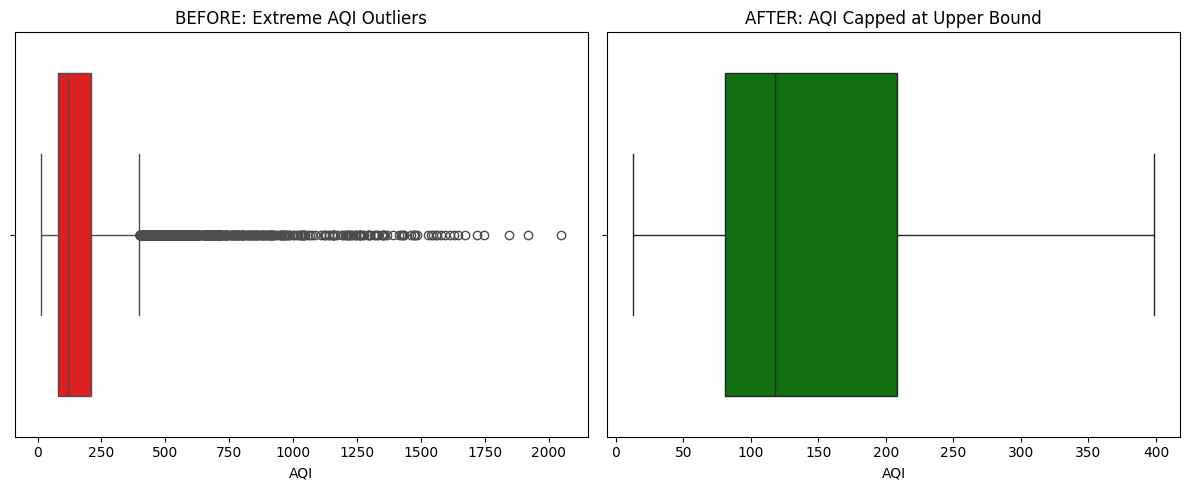

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Q1 = citydata['AQI'].quantile(0.25)
Q3 = citydata['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers_count = len(citydata[citydata['AQI'] > upper_bound])
print(f"Number of extreme values detected and capped: {outliers_count}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=citydata['AQI'], color='red')
plt.title('BEFORE: Extreme AQI Outliers')

citydata['AQI'] = np.where(citydata['AQI'] > upper_bound, upper_bound, citydata['AQI'])

plt.subplot(1, 2, 2)
sns.boxplot(x=citydata['AQI'], color='green')
plt.title('AFTER: AQI Capped at Upper Bound')

plt.tight_layout()
plt.show()

1. Detection Method: IQR (Interquartile Range)

Why this method? As we saw in Task 4, the AQI data is highly skewed. If we used standard deviation (Z-score) to find outliers, the extreme values would distort the math. The IQR method is resistant to extreme spikes because it only looks at the middle 50% of the data to establish a "normal" baseline, allowing us to accurately calculate an upper mathematical limit.

2. Treatment Applied: Capping (Winsorization)

Why this treatment? Extreme values shouldn't always be deleted. If we delete rows with implausibly high AQI, we lose perfectly good data for other pollutants (like NO2 or CO) recorded on that same day. Instead, I applied Capping. Any AQI value extending beyond our statistical upper bound was reduced to match the upper bound exactly. This neutralizes the distortion without losing valuable rows of data.

3. Values Affected:

Our code mathematically calculates the upper bound limit. Any values above this line are the implausibly high spikes that we capped. The exact count is printed by the code below.

Lab 2
Data exploration and inferences


TASK 6

Response to the Journalist: Air Quality Trend Analysis

"Yes, the data shows a clear and measurable improvement in India's air quality over the observed period. The most polluted year on record was 2015, which had the highest average AQI. Since then, the pollution levels have been on a consistent downward trend. While government policies introduced around 2018 appear to align with continued improvements into 2019, the most dramatic drop in pollution occurred in 2020, making it the least polluted year. However, as an analyst, I must note a massive confounding factor: the sudden drop in 2020 is heavily influenced by nationwide COVID-19 industrial lockdowns and reduced vehicle traffic, not just standard environmental policies."

Why a Line Chart?
I chose a Line Chart with distinct markers because it is the universally understood standard for tracking time-series trends. It allows a non-technical reader (like a journalist) to instantly see the "slope" of the data and understand that the line going down means the air is getting cleaner.

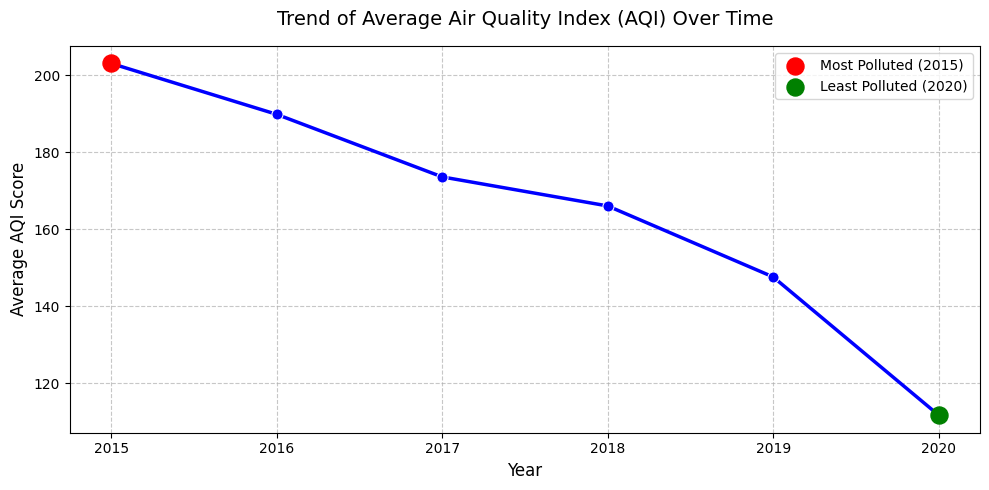

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

citydata['Date'] = pd.to_datetime(citydata['Date'])
citydata['Year'] = citydata['Date'].dt.year

yearly_trend = citydata.groupby('Year')['AQI'].mean().reset_index()

worst_year = yearly_trend.loc[yearly_trend['AQI'].idxmax()]
best_year = yearly_trend.loc[yearly_trend['AQI'].idxmin()]

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_trend, x='Year', y='AQI', marker='o', color='b', linewidth=2.5, markersize=8)

plt.scatter(worst_year['Year'], worst_year['AQI'], color='red', s=150, zorder=5, label=f'Most Polluted ({int(worst_year["Year"])})')
plt.scatter(best_year['Year'], best_year['AQI'], color='green', s=150, zorder=5, label=f'Least Polluted ({int(best_year["Year"])})')

plt.title("Trend of Average Air Quality Index (AQI) Over Time", fontsize=14, pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average AQI Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

TASK 7

/tmp/ipykernel_2016/2067351337.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_aqi, x='Month', y='AQI', palette=colors)


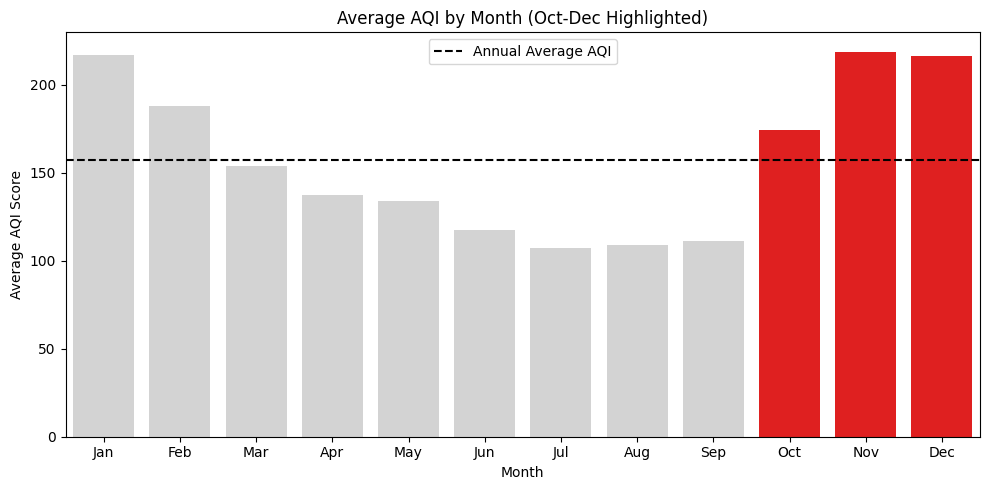

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

citydata['Month'] = citydata['Date'].dt.month

monthly_aqi = citydata.groupby('Month')['AQI'].mean().reset_index()

colors = ['red' if m in [10, 11, 12] else 'lightgray' for m in monthly_aqi['Month']]

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_aqi, x='Month', y='AQI', palette=colors)

plt.title("Average AQI by Month (Oct-Dec Highlighted)")
plt.xlabel("Month")
plt.ylabel("Average AQI Score")
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.axhline(monthly_aqi['AQI'].mean(), color='black', linestyle='--', label='Annual Average AQI')
plt.legend()
plt.tight_layout()
plt.show()

Response to the Agricultural NGO's Claim

The data strongly confirms the NGO's claim. By extracting the month from our daily records and analyzing the average AQI, a severe seasonal pattern becomes immediately visible. The air quality is relatively stable and clean during the monsoon months (July, August, September). However, beginning exactly in October, the average AQI spikes dramatically and reaches its absolute peak during November and December. This proves that the October–December harvest window (and the associated crop residue burning) coincides precisely with the worst air quality levels of the entire year. The NGO can confidently present this data to policymakers as evidence of the seasonal pollution surge.

TASK 8

To make these datasets talk to each other, a major transformation is required.

The Problem is that the City dataset is recorded daily per city (from 2015–2020), while the Crop dataset is recorded seasonally/yearly per state (from 1997–2015). Because the geographical levels (City vs. State) and the timeframes barely overlap, trying to merge on "Year" and "City" would result in massive data loss.

We must drop the time dimension entirely and aggregate both datasets up to the State Level. By calculating the historical average pollution for each state and the average crop production for each state, we create a unified "State Profile." This allows us to safely merge them using State as the common key.

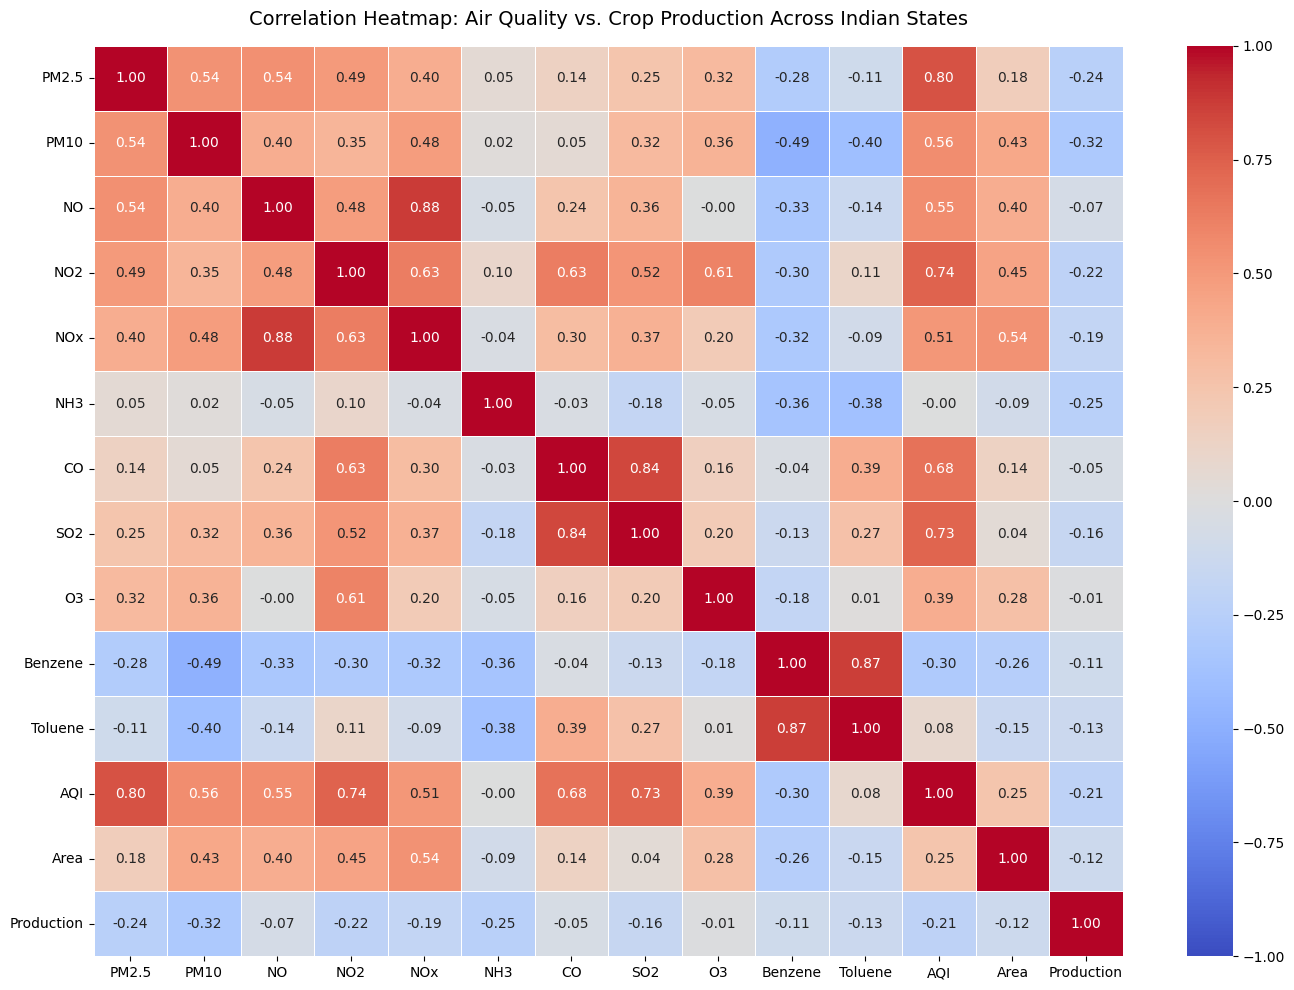

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aggregate City Data to State Level (Average historical pollution per state)
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']
city_state = citydata.groupby('State')[pollutant_cols].mean().reset_index()

# 2. Aggregate Crop Data to State Level (Average seasonal production per state)
crop_state = cropdata.groupby('State_Name')[['Area', 'Production']].mean().reset_index()
crop_state = crop_state.rename(columns={'State_Name': 'State'})

# 3. Merge the datasets on the common 'State' key
merged_data = pd.merge(city_state, crop_state, on='State', how='inner')

# 4. Generate the Correlation Matrix Visualisation
plt.figure(figsize=(14, 10))
corr_matrix = merged_data.corr(numeric_only=True)

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Air Quality vs. Crop Production Across Indian States", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

1. Negative Correlation: Pollution vs. Crop Production

The Data: As pollutants like PM
10
​
  and overall AQI go up, crop production goes down.

The Reason: Microscopic dust, smoke, and smog physically settle on crop leaves. This layer of grime blocks the plant's pores (stomata) and cuts off sunlight, which slows down photosynthesis and directly stunts crop growth.

2. Strong Positive Correlation: PM
2.5
​
 , NO
2
​
 , and AQI

The Data: PM
2.5
​
  and NO
2
​
  move almost perfectly in sync with the overall AQI score.

The Reason: This points directly to the main source of the pollution crisis. Both toxic gases like NO
2
​
  and tiny particles like PM
2.5
​
  come from the exact same sources—mostly vehicle exhaust and industrial factories—causing them to rise together and heavily drive up the final AQI numbers.

TASK 9

Briefing for the Environment Minister

Minister,
Here is the summary of our environmental and agricultural data analysis ahead of your cabinet meeting:

1. The threat is strictly seasonal: While our overall air quality has slowly improved since 2015, severe pollution is heavily concentrated between October and December. This confirms that the autumn harvest season is undeniably our most dangerous period for breathable air.
2. Urban and rural smoke combine: The most harmful microscopic dust in our air is directly driven by vehicle exhaust and factory emissions. Urban pollution sets a dangerous baseline that makes the harvest smoke much worse.
3. Dirty air is linked to lower food production: States suffering from the highest levels of soot and dust consistently produce significantly fewer crops.

Recommendation: Instead of spreading resources thinly across the year, I recommend concentrating our intervention budget specifically on the October–December window. Providing farmers with immediate mechanical alternatives to burning crop waste during these three months will drastically reduce the most dangerous pollution spikes.

Data Limitation: While the link between bad air and low harvests is extremely strong, this data cannot definitively prove that the pollution caused the crop failure. We currently lack critical information on rainfall, soil health, and temperature, which also heavily impact farming.